# Proyecto: Regresión Bayesiana Beta para Variables Proporcionales

## Objetivo general

El objetivo de este proyecto es construir modelos bayesianos para variables continuas acotadas en el intervalo:

$$
0 < y_i < 1
$$

utilizando regresión Beta.

Los estudiantes deberán implementar modelos bayesianos en NumPyro y analizar:

- comportamiento probabilístico,
- interpretación de proporciones,
- regularización,
- incertidumbre posterior,
- y capacidad predictiva.

El proyecto busca integrar:

- modelos lineales generalizados,
- inferencia bayesiana,
- modelación de proporciones,
- métodos MCMC,
- y análisis de datos acotados.

---

# Notación

- $y_i$ representa una proporción o tasa.
- $x_i$ es el vector de covariables.
- $\beta$ representa los coeficientes de regresión.
- $\mu_i$ representa la media condicional.
- $\phi$ representa el parámetro de precisión.
- $\tau$ es el hyperparámetro de regularización.
- $X$ representa la matriz de diseño.
- $n$ es el número de observaciones.
- $p$ es el número de covariables.

---

# 1. Variables proporcionales

La regresión Beta se utiliza cuando la variable respuesta satisface:

$$
0 < y_i < 1
$$

y representa:

- proporciones,
- probabilidades,
- tasas,
- porcentajes normalizados,
- fracciones.

Ejemplos:

- tasa de conversión,
- proporción de votos,
- porcentaje de ocupación,
- proporción de éxito,
- índices normalizados.

---

# 2. Distribución Beta

El modelo asume:

$$
y_i
\sim
\text{Beta}(\alpha_i,\beta_i)
$$

La distribución Beta es flexible y puede modelar:

- asimetría,
- bimodalidad,
- concentraciones cerca de 0 o 1,
- distribuciones aproximadamente uniformes.

---

# 3. Parametrización mediante media y precisión

En este proyecto se utiliza la parametrización:

$$
\alpha_i
=
\mu_i\phi
$$

$$
\beta_i
=
(1-\mu_i)\phi
$$

donde:

- $\mu_i$ representa la media condicional,
- $\phi$ representa el parámetro de precisión.

---

# 4. Predictor lineal

La media condicional se modela mediante:

$$
\mu_i
=
g^{-1}(x_i^T\beta)
$$

donde:

- $g^{-1}$ es una función de enlace inversa,
- $\mu_i \in (0,1)$.

---

# 5. Función sigmoide

En este proyecto se utiliza la función logística:

$$
\mu_i
=
\frac{1}{1+\exp(-x_i^T\beta)}
$$

La función sigmoide garantiza:

$$
0 < \mu_i < 1
$$

---

# 6. Otras funciones de enlace

Aunque en este proyecto se utiliza la función sigmoide, pueden utilizarse otras funciones de enlace.

Ejemplos comunes:

---

## Link Logit

$$
g(\mu)
=
\log\left(
\frac{\mu}{1-\mu}
\right)
$$

Es el enlace más utilizado.

---

## Link Probit

$$
g(\mu)
=
\Phi^{-1}(\mu)
$$

donde $\Phi$ es la CDF de una Normal estándar.

---

## Complementary Log-Log

$$
g(\mu)
=
\log(-\log(1-\mu))
$$

Este enlace es asimétrico y útil en ciertos problemas de tasas.

---

## Cauchit

Basado en la distribución Cauchy:

$$
g(\mu)
=
\tan\left(\pi(\mu-1/2)\right)
$$

Puede producir colas más pesadas.

---

# 7. Parámetro de precisión

El modelo incluye:

$$
\phi
\sim
\text{HalfNormal}(10)
$$

El parámetro $\phi$ controla la dispersión de la distribución Beta.

Interpretación:

- $\phi$ pequeño:
  - mayor variabilidad,
  - datos más dispersos.

- $\phi$ grande:
  - observaciones más concentradas alrededor de $\mu_i$.

---

# 8. Priors Bayesianos

Los coeficientes utilizan:

$$
\beta_j
\sim
\mathcal{N}(0,\tau^2)
$$

con:

$$
\tau
\sim
\text{HalfNormal}(10)
$$

Esto induce regularización sobre los coeficientes.

---

# 9. Inferencia Bayesiana

El objetivo es aproximar la distribución posterior:

$$
p(\beta,\tau,\phi \mid X,y)
$$

utilizando:

- Markov Chain Monte Carlo (MCMC),
- Hamiltonian Monte Carlo (HMC),
- No-U-Turn Sampler (NUTS).

El resultado final consiste en muestras posteriores de los parámetros y distribuciones predictivas.

---

# 10. Validación Cruzada

La evaluación del modelo se realizará mediante validación cruzada.

En cada fold:

1. se ajusta el modelo,
2. se generan muestras posteriores,
3. se evalúa desempeño fuera de muestra.

---

# 11. Métrica de evaluación

La métrica principal será el Negative Log-Likelihood (NLL):

$$
\text{NLL}
=
-\log p(y_{\text{valid}} \mid X_{\text{valid}})
$$

Interpretación:

- menor NLL:
  - mejor capacidad predictiva,
  - mejor calibración probabilística.

- mayor NLL:
  - peor desempeño predictivo.

---

# 12. Visualización y análisis posterior

Los estudiantes deberán analizar:

- distribuciones posteriores de coeficientes,
- incertidumbre posterior,
- comportamiento del parámetro $\phi$,
- estabilidad predictiva,
- interpretación de efectos.

También deberán visualizar:

- densidades posteriores,
- distribuciones predictivas,
- ajuste entre observaciones y predicciones.

---

# 13. Objetivos específicos del proyecto

Los estudiantes deberán:

1. Seleccionar un dataset real con variables proporcionales.
2. Realizar limpieza y preprocesamiento.
3. Implementar regresión Beta bayesiana.
4. Ajustar el modelo mediante NUTS.
5. Analizar convergencia MCMC.
6. Comparar funciones de enlace opcionalmente.
7. Evaluar desempeño predictivo.
8. Interpretar parámetros posteriores.
9. Elaborar conclusiones estadísticas.

---

# 14. Entregables sugeridos

El proyecto deberá incluir:

- notebook reproducible,
- explicación teórica,
- análisis exploratorio,
- implementación del modelo,
- métricas de evaluación,
- visualizaciones posteriores,
- interpretación estadística,
- conclusiones.

In [5]:
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, log_likelihood
import jax.random as random
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, ParameterSampler, KFold
from scipy.stats import distributions as scdist
import numpyro
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

numpyro.set_host_device_count(3)
plt.style.use("default")


In [6]:
n = 5000
p = 7
phi = 100.0
seed = 12346

np.random.seed(seed)

X = np.random.rand(n, p)

X = np.hstack((np.ones((n, 1)), X))

beta = 0.5*np.random.rand(p+1)

mu = jax.nn.sigmoid(X @ beta)

y = dist.Beta(mu *phi, (1-mu)*phi).sample(random.PRNGKey(seed))

X = jnp.array(X)
y = jnp.array(y)


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=18081997)

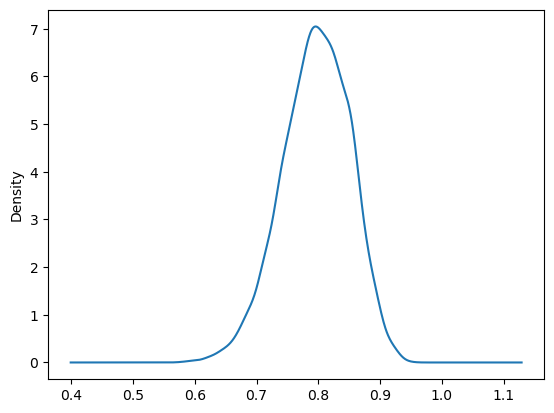

In [10]:
pd.DataFrame(y).plot.kde(legend=None)
plt.show()

In [11]:
def beta_regression(X, y=None):

    n, p = X.shape

    tau = numpyro.sample("tau", dist.HalfNormal(10.0))

    phi = numpyro.sample("phi", dist.HalfNormal(10.0))

    Beta = numpyro.sample("beta", dist.Normal(0., tau).expand([p]).to_event(1))

    mu = jax.nn.sigmoid(jnp.matmul(X, Beta))

    with numpyro.plate("data", n):

        numpyro.sample("y", dist.Beta(mu*phi, (1-mu)*phi), obs=y)

In [12]:
burn_in = 1500
num_samples = 2000
num_chains = 3
chain_method = "parallel"

seed = 18081997

In [13]:
rng_key = random.PRNGKey(seed)

kernel = NUTS(beta_regression)

mcmc = MCMC(kernel,
            num_samples=num_samples,
            num_chains=num_chains,
            num_warmup=burn_in,
            chain_method=chain_method,
            progress_bar=True)

mcmc.run(rng_key, X_train, y_train)

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

In [14]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      0.43      0.02      0.43      0.40      0.46   3812.80      1.00
   beta[1]      0.11      0.01      0.11      0.09      0.13   6996.34      1.00
   beta[2]      0.39      0.01      0.39      0.37      0.41   6382.38      1.00
   beta[3]      0.17      0.01      0.17      0.15      0.19   6063.15      1.00
   beta[4]      0.34      0.01      0.34      0.32      0.36   6171.59      1.00
   beta[5]      0.50      0.01      0.50      0.48      0.52   5417.93      1.00
   beta[6]      0.24      0.01      0.24      0.21      0.26   7117.63      1.00
   beta[7]      0.14      0.01      0.14      0.12      0.16   6116.27      1.00
       phi     94.91      2.06     94.91     91.58     98.26   7260.82      1.00
       tau      0.38      0.12      0.36      0.22      0.55   4354.89      1.00

Number of divergences: 0


In [23]:
samples = mcmc.get_samples()

KeyError: 'W1'

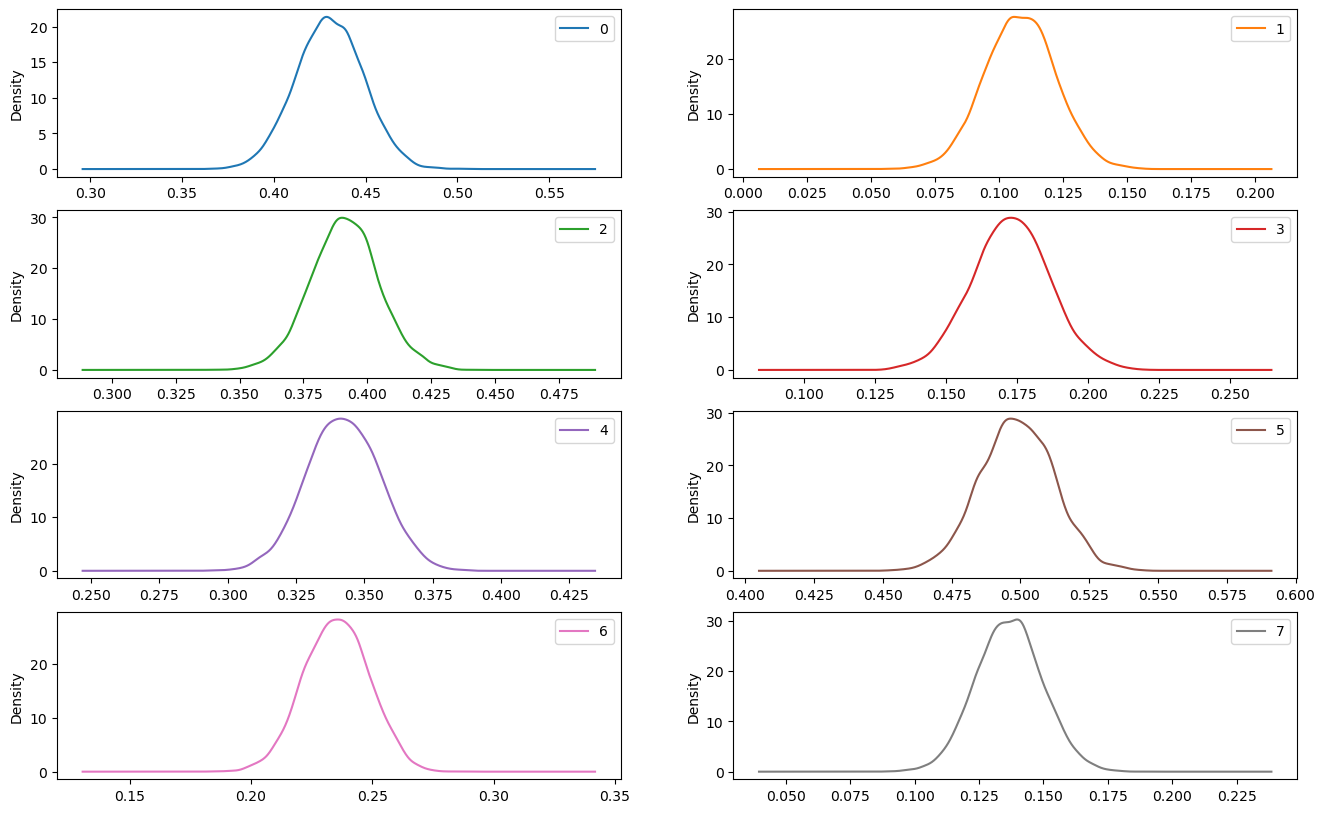

In [16]:
pd.DataFrame(samples["beta"]).plot.kde(subplots=True, layout=(4, 2), sharex=False, figsize=(16, 10))
plt.show()

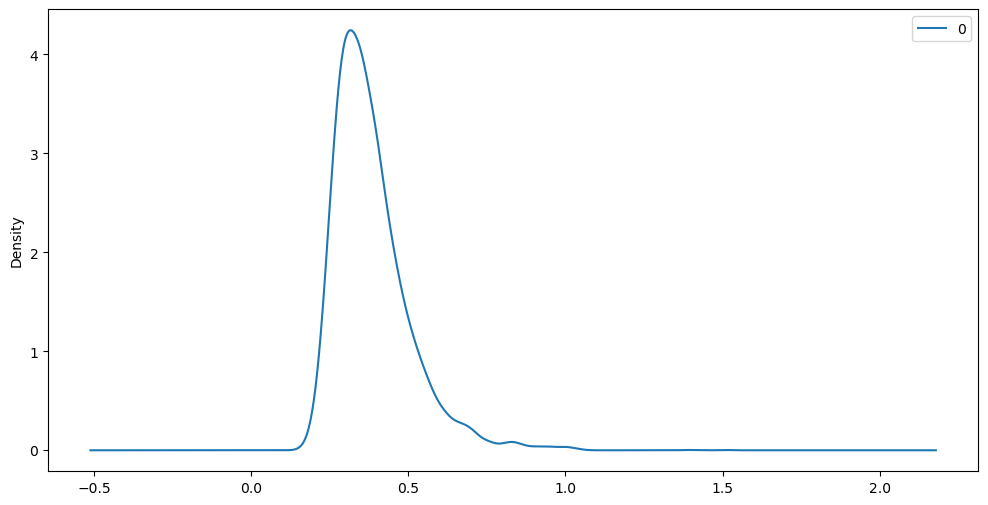

In [17]:
pd.DataFrame(samples["tau"]).plot.kde(figsize=(12, 6))
plt.show()

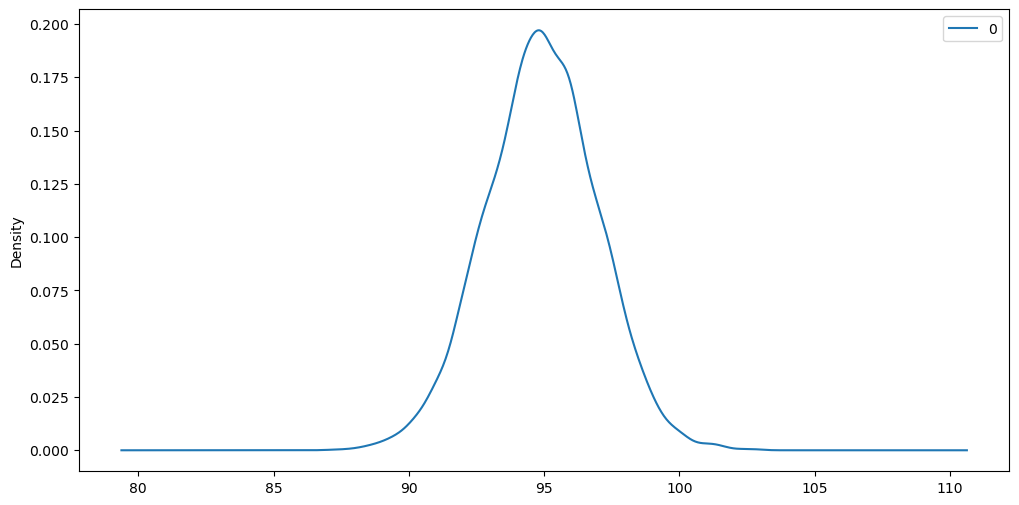

In [18]:
pd.DataFrame(samples["phi"]).plot.kde(figsize=(12, 6))
plt.show()

In [19]:
nll_samples = -log_likelihood(beta_regression, samples, X_val, y_val)["y"].mean(axis=1)

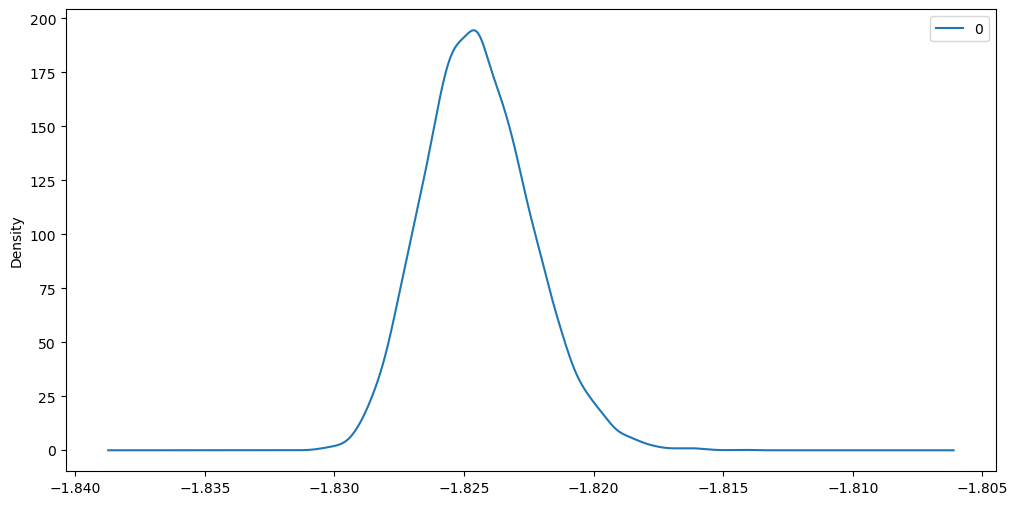

In [20]:
pd.DataFrame(nll_samples).plot.kde(figsize=(12, 6))
plt.show()

In [21]:
y_pred_samples = jax.nn.sigmoid(jnp.matmul(samples["beta"], X_val.T))

y_mean = jnp.mean(y_pred_samples, axis=0)
y_low = jnp.percentile(y_pred_samples, 2.5, axis=0)
y_high = jnp.percentile(y_pred_samples, 97.5, axis=0)

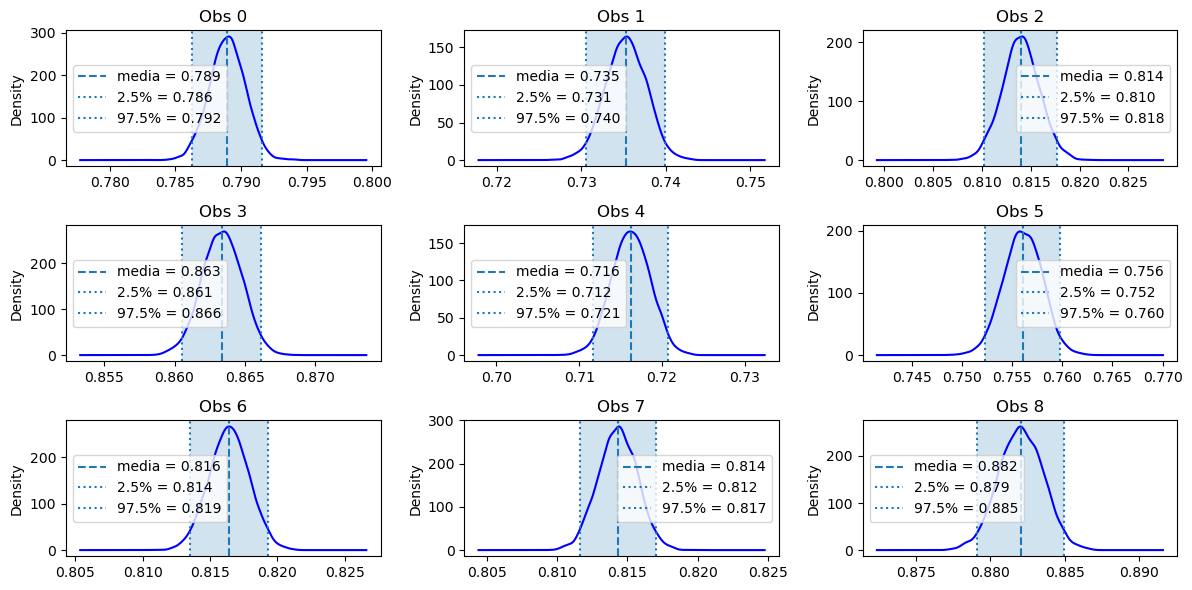

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(12, 6))

axes = axes.flatten()

for i, ax in enumerate(axes):
    # KDE
    pd.Series(np.array(y_pred_samples[:, i])).plot.kde(ax=ax, color="blue")

    # media
    ax.axvline(
        y_mean[i],
        linestyle="--",
        label=f"media = {y_mean[i]:.3f}"
    )

    # intervalos
    ax.axvline(
        y_low[i],
        linestyle=":",
        label=f"2.5% = {y_low[i]:.3f}"
    )

    ax.axvline(
        y_high[i],
        linestyle=":",
        label=f"97.5% = {y_high[i]:.3f}"
    )

    ax.axvspan(y_low[i], y_high[i], alpha=0.2)

    ax.set_title(f"Obs {i}")

    ax.legend()

plt.tight_layout()
plt.show()
